# Imbalanced Data (Simple Version)

This notebook shows three things in a simple flow:
1. Why imbalance gives misleading accuracy.
2. How recall exposes poor models.
3. How sampling methods help.

Methods covered in order:
1. Random Undersampling
2. Random Oversampling
3. SMOTE

## What is imbalanced data?

Imbalanced data means one class has many more samples than the other.

Example: 98% class 0 and 2% class 1.

In this case, a model can get high accuracy by predicting mostly class 0.
So we must check **recall** for class 1.

- High accuracy + low recall = poor model for minority class.

In [29]:
# 1) Imports
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler, SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Setup complete.')

Setup complete.


Class counts:
0    11697
1      303
Name: count, dtype: int64


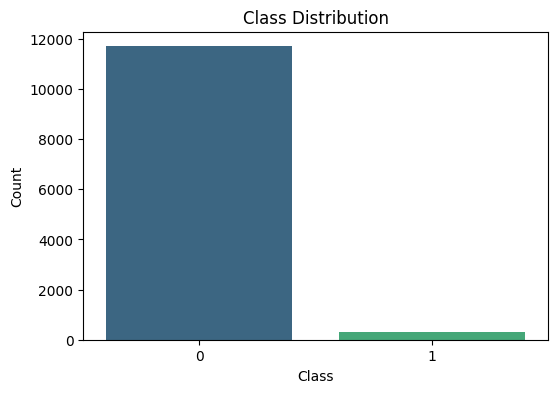

In [30]:
# 2) Create imbalanced dataset
X, y = make_classification(
    n_samples=12000,
    n_features=20,
    n_informative=6,
    n_redundant=4,
    weights=[0.98, 0.02],
    random_state=RANDOM_STATE,
)

class_counts = pd.Series(y).value_counts().sort_index()
print('Class counts:')
print(class_counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=class_counts.index.astype(str), y=class_counts.values, palette='viridis')
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [31]:
# 3) Train-test split + simple evaluation function
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y,
)

print('Train distribution:', np.bincount(y_train))
print('Test distribution :', np.bincount(y_test))

results = []

def evaluate_model(model_name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    results.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
    })

    print(f'\n{model_name}')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1-score : {f1:.4f}')

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

Train distribution: [8773  227]
Test distribution : [2924   76]



Baseline (No sampling)
Accuracy : 0.9760
Precision: 1.0000
Recall   : 0.0526
F1-score : 0.1000


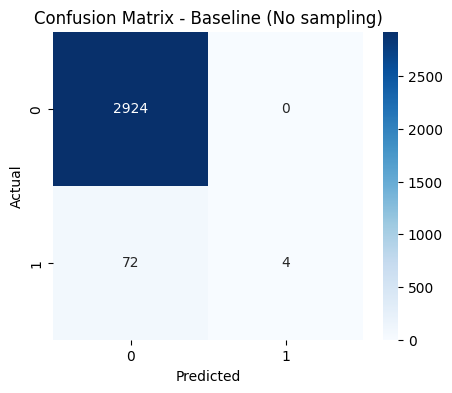

If recall is very low here, model is poor for minority class.


In [ ]:
# 4) Baseline model (no sampling)
baseline = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)

y_pred_base = baseline.predict(X_test)
evaluate_model('Baseline (No sampling)', y_test, y_pred_base)

# If recall is very low here, model is poor for minority class.

## Notes: Sampling Methods (What They Do and Why They Help)

### 1) Random Undersampling
- What it does: Reduces majority class samples to balance the dataset.
- How it helps: Minority class gets equal importance during training, so recall usually improves.
- Trade-off: Can lose useful majority-class information.
- Best when: Dataset is very large and majority class has many redundant points.

### 2) Random Oversampling
- What it does: Duplicates minority class samples until classes are balanced.
- How it helps: Model sees minority class more often and learns it better.
- Trade-off: Can overfit because exact minority points are repeated.
- Best when: You want a simple and fast baseline fix.
- It can cause Overfitting to avoit this we use SMOTE

### 3) SMOTE (Synthetic Minority OverSampling Technique)
- What it does: Creates synthetic minority samples (not exact duplicates) using nearest neighbors.
- How it helps: Adds new minority patterns, often improving generalization more than random oversampling.
- Trade-off: Can generate noisy samples if minority data is very scattered.
- Best when: You want a stronger oversampling approach than simple duplication.

- NOTE - here we use KNN
- formula - sample-[factor*(sample-neighbour)]

##### Disadvantages of SMOTE
- Does Not Handle Categorical Data Well
- Computational Complexity
- Dependency on the Choice of Neighbors
- Sensitive to Outliers
- Balance Achieved May Not Reflect True Nature

### Quick idea
- Imbalanced model usually gives high accuracy but poor minority recall.
- Sampling methods shift training attention toward minority class and improve recall.

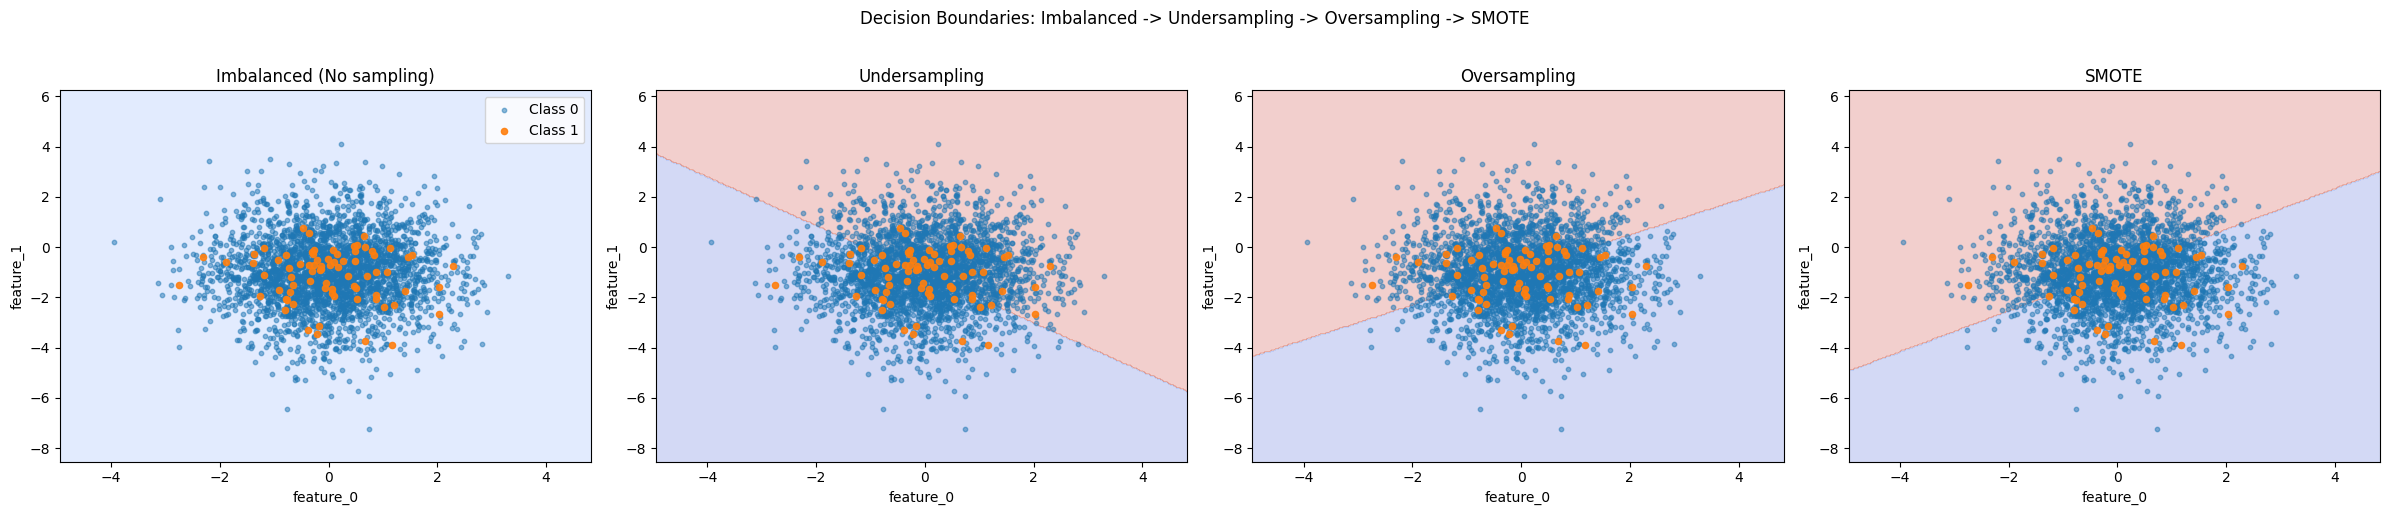

In [36]:
# 7) Decision boundary plots (simple 2D view)
# For plotting only, we use first 2 features.

X2 = X[:, :2]
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

methods = [
    ('Imbalanced (No sampling)', None),
    ('Undersampling', RandomUnderSampler(random_state=RANDOM_STATE)),
    ('Oversampling', RandomOverSampler(random_state=RANDOM_STATE)),
    ('SMOTE', SMOTE(random_state=RANDOM_STATE)),
]

x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))

fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, (name, sampler) in zip(axes, methods):
    if sampler is None:
        X_res, y_res = X2_train, y2_train
    else:
        X_res, y_res = sampler.fit_resample(X2_train, y2_train)

    model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    model.fit(X_res, y_res)

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.scatter(X2_test[y2_test == 0, 0], X2_test[y2_test == 0, 1], s=10, alpha=0.5, label='Class 0')
    ax.scatter(X2_test[y2_test == 1, 0], X2_test[y2_test == 1, 1], s=20, alpha=0.9, label='Class 1')
    ax.set_title(name)
    ax.set_xlabel('feature_0')
    ax.set_ylabel('feature_1')

axes[0].legend(loc='upper right')
plt.suptitle('Decision Boundaries: Imbalanced -> Undersampling -> Oversampling -> SMOTE', y=1.02)
plt.tight_layout()
plt.show()

Random Undersampling train distribution: [227 227]

Random Undersampling
Accuracy : 0.7447
Precision: 0.0720
Recall   : 0.7632
F1-score : 0.1315


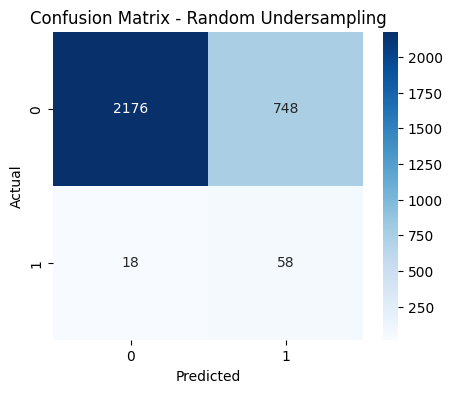

In [37]:
# 5) Random Undersampling
rus = RandomUnderSampler(random_state=RANDOM_STATE)
X_res_under, y_res_under = rus.fit_resample(X_train, y_train)

print('Random Undersampling train distribution:', np.bincount(y_res_under))

model_under = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
model_under.fit(X_res_under, y_res_under)

y_pred_under = model_under.predict(X_test)
evaluate_model('Random Undersampling', y_test, y_pred_under)

Random Oversampling train distribution: [8773 8773]

Random Oversampling
Accuracy : 0.7727
Precision: 0.0780
Recall   : 0.7368
F1-score : 0.1411


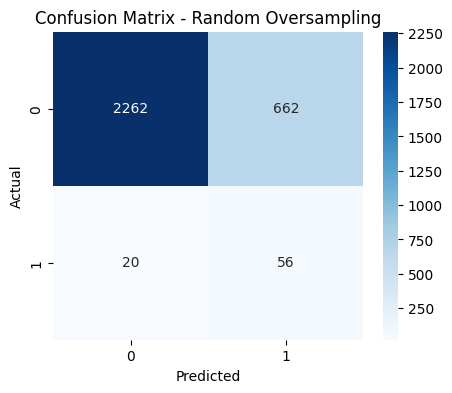

In [38]:
# 6) Random Oversampling
ros = RandomOverSampler(random_state=RANDOM_STATE)
X_res_over, y_res_over = ros.fit_resample(X_train, y_train)

print('Random Oversampling train distribution:', np.bincount(y_res_over))

model_over = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
model_over.fit(X_res_over, y_res_over)

y_pred_over = model_over.predict(X_test)
evaluate_model('Random Oversampling', y_test, y_pred_over)

SMOTE train distribution: [8773 8773]

SMOTE
Accuracy : 0.7800
Precision: 0.0793
Recall   : 0.7237
F1-score : 0.1429


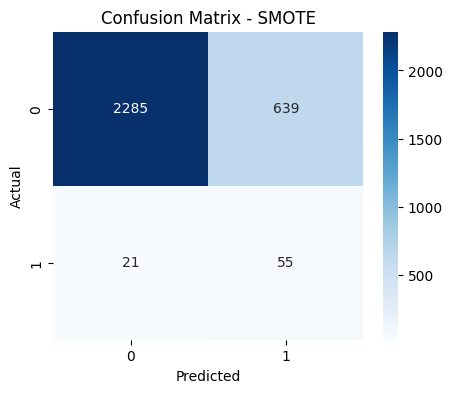

In [39]:
# 7) SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
X_res_smote, y_res_smote = smote.fit_resample(X_train, y_train)

print('SMOTE train distribution:', np.bincount(y_res_smote))

model_smote = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
model_smote.fit(X_res_smote, y_res_smote)

y_pred_smote = model_smote.predict(X_test)
evaluate_model('SMOTE', y_test, y_pred_smote)

In [41]:
# 8) Simple comparison table
results_df = pd.DataFrame(results)

# Keep only latest run of each model name
results_df = results_df.drop_duplicates(subset='Model', keep='last')

order = ['Baseline (No sampling)', 'Random Undersampling', 'Random Oversampling', 'SMOTE']
results_df['Order'] = results_df['Model'].map({name: i for i, name in enumerate(order)})
results_df = results_df.sort_values('Order').drop(columns='Order')

print('Models in learning order:')
print(results_df.round(4).to_string(index=False))

best_recall_row = results_df.sort_values('Recall', ascending=False).iloc[0]
print('\nBest Recall Model:', best_recall_row['Model'])
print('Best Recall Value:', round(float(best_recall_row['Recall']), 4))

Models in learning order:
                 Model  Accuracy  Precision  Recall     F1
Baseline (No sampling)    0.9760     1.0000  0.0526 0.1000
  Random Undersampling    0.7447     0.0720  0.7632 0.1315
   Random Oversampling    0.7727     0.0780  0.7368 0.1411
                 SMOTE    0.7800     0.0793  0.7237 0.1429

Best Recall Model: Random Undersampling
Best Recall Value: 0.7632


## Final Notes

- Check **recall** when classes are imbalanced.
- Accuracy alone can be misleading.
- Sampling methods help detect minority class better.
- In this notebook, methods are shown in this order:
  1. Undersampling
  2. Oversampling
  3. SMOTE